# Environments

[![Click and Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/metadriverse/metadrive/blob/main/documentation/source/rl_environments.ipynb)

<a id='environments'></a>

By default, there are 5 off-the-shelf RL environments:
- Generalization environment
- VaryingDynamics environment
- Safe RL environment
- MARL environment
- Real-world environment


## Generalization Environment

<p align="center"><iframe width="848" height="477" src="https://www.youtube.com/embed/hL0XDfNHYjA?si=7cn1CpzgpNAf8OAd" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe></p>

We developed an RL environment through procedural generation where maps are composed by connecting various types of road blocks and then traffic vehicles are scattered on maps randomly.
Thus the environment can generate an unlimited number of diverse driving scenarios.
By training RL agents in one set of scenarios and testing them in another held-out set, we can benchmark the generalizability of the driving policy. 


<img src="figs/blocks_and_big_case_page.jpg" width="864" class="center">

You can experience this environment through the following script:
```bash
# args
# --observation: lidar, rgb_camera
python -m metadrive.examples.drive_in_single_agent_env --observation lidar
```
And the following script creates basic environments if you are using this environment in your code:

In [ ]:
from metadrive import MetaDriveEnv
import tqdm

training_env = MetaDriveEnv(dict(
    num_scenarios=1000,
    start_seed=1000,
    random_lane_width=True,
    random_agent_model=True,
    random_lane_num=True
))


test_env = MetaDriveEnv(dict(
    num_scenarios=200,
    start_seed=0,
    random_lane_width=True,
    random_agent_model=True,
    random_lane_num=True
))


User can specify the training set with 1000 driving scenarios by setting `num_scenarios=1000` and `start_seed=1000`, while creating the test set by setting `num_scenarios=200` and `start_seed=0`.
In this case, the scenarios generated by random seeds [1000, 1999] will be used to train the agents and those by [0, 199] will be used to test the trained agent.

**Note: Please note that each process should only have one single MetaDrive instance due to the limit of the underlying simulation engine, but sometimes we want to have one environment for training and the other one for testing.** There are two ways to overcome this:
1. Launching the training environment and test environment in two separate processes using tools like `Ray` or `stablebaseline3.SubprocVecEnv`. Generally, We use [Ray/RLLib](https://docs.ray.io/en/latest/rllib.html) to train RL agents. The training and test environments are naturally hosted in training workers (processes) and evaluation workers. Therefore we do not worry about this singleton problem.
2. Closing the training environment `training_env.close()` before launch the test environment via `test_env.reset()`. After evaluation, it is allowed to restore the training environment after closing the test environment by simply `training_env.reset()`. An example is as follows.

In [ ]:
for training_epoch in range(2):
    # training
    training_env.reset()
    print("\nStart fake training epoch {}...".format(training_epoch))
    for _ in range(10):
        # execute 10 step
        training_env.step(training_env.action_space.sample())
    training_env.close()

    # evaluation
    print("Evaluate checkpoint for training epoch {}...\n".format(training_epoch))
    test_env.reset()
    for _ in range(10):
        # execute 10 evaluation step
        test_env.step(test_env.action_space.sample())
    test_env.close()

assert test_env.config is not training_env.config

### Randomization

The other config `dict(random_lane_width=True, random_agent_model=True, random_lane_num=True)` specifies if the agent model, lane num and lane width will be randomized to make the scenarios more diverse. In the following example, we sample 50 scenarios from the training set and show the statistics.

In [9]:
from metadrive.component.vehicle.vehicle_type import vehicle_type

# container
env_seed=1000
lane_nums = set()
lane_widths = set()
vehicle_models = set()
traffic_vehicle_models = set()

# collect statistics
maps_to_sample = 50
end_seed = training_env.config["start_seed"] + maps_to_sample
for env_seed in tqdm.tqdm(range(training_env.config["start_seed"], end_seed)):
    
    # use `seed` argument to choose which scenario to run
    training_env.reset(seed=env_seed)
    lane_nums.add(training_env.current_map.config["lane_num"]) 
    lane_widths.add(training_env.current_map.config["lane_width"])
    vehicle_models.add(training_env.agent.__class__.__name__)
    traffic_models = set([obj.__class__ for obj in training_env.engine.traffic_manager.spawned_objects.values()])
    traffic_vehicle_models = traffic_vehicle_models.union(traffic_models)
    assert vehicle_type[training_env.agent.config["vehicle_model"]] is training_env.agent.__class__
    
training_env.close()

# show information
print("Number of lanes in {} maps are: {}".format(maps_to_sample, lane_nums))
print("{} maps have {} different widths".format(maps_to_sample, len(lane_widths)))
print("The policy is learning to drive {} types of vehicles".format(len(vehicle_models)))
print("There are {} types of traffic vehicles".format(len(traffic_vehicle_models)))

# check
assert lane_nums == {2, 3}
assert len(lane_widths) == 50
assert len(vehicle_models) == 5
assert len(traffic_vehicle_models) == len(vehicle_models) - 1

  0%|                                                                                                                                                                                | 0/50 [00:00<?, ?it/s][INFO] Assets version: 0.4.1.2
[INFO] Known Pipes: glxGraphicsPipe
[INFO] Start Scenario Index: 1000, Num Scenarios : 1000
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.31it/s]

Number of lanes in 50 maps are: {2, 3}
50 maps have 50 different widths
The policy is learning to drive 5 types of vehicles
There are 4 types of traffic vehicles


There are more config terms for customizing this environment. The full config with comprehensive annotations is at [METADRIVE_DEFAULT_CONFIG](https://github.com/metadriverse/metadrive/blob/main/metadrive/envs/metadrive_env.py).
Most of the fields are configuration for the reward, cost, termination function, while some of them can be changed to customize the environment. 

### Traffic

The first important field is `traffic_density`. The default value is `0.1`. Increasing this value will make the traffic flow dense. **Note: there is not an obvious relationship between this value and the number of vehicles.** The following code calculates the average number of vehicles in environments with different `traffic_density`. We also turn off the logging, so you won't see any `[INFO]` level messages.

In [10]:
from metadrive import MetaDriveEnv
import tqdm
import logging

# Default, traffic density=0.1
simple_env = MetaDriveEnv(dict(num_scenarios=10, 
                               start_seed=0, 
                               log_level=logging.WARNING))
# traffic density=0.5
complex_env = MetaDriveEnv(dict(num_scenarios=10, 
                                start_seed=0, 
                                traffic_density=0.5,
                                log_level=50)) # 50 == logging.WARNING

def calculate_traffic_vehicles(env, name):
    num_v = 0
    for seed in range(10):
        env.reset(seed=seed)
        num_v += len(env.engine.traffic_manager.spawned_objects)
    print("There are averagely {} vehicles in {}".format(num_v/10, name))
    env.close()

calculate_traffic_vehicles(simple_env, "environment with 0.1 density")
calculate_traffic_vehicles(complex_env, "environment with 0.5 density")

There are averagely 8.0 vehicles in environment with 0.1 density
There are averagely 43.4 vehicles in environment with 0.5 density


To maximize the interaction between ego car and traffic vehicles. The default traffic mode is `trigger`. In this mode, the traffic vehicles are scattered and keep static on the map and will be triggered to move only when the ego car is close to them. After the traffic vehicles reach the destination, they will be deleted from the scene. In the following example, the traffic vehicles in the roundabout are triggered when the `step > 100` and the ego car enters the roundabout. It also demonstrates how to use top-down renderer. More details can be found at <a href="top_down_render.html#top-down-renderer">Top-down Renderer</a>.

In [ ]:
from metadrive import MetaDriveEnv
from metadrive.policy.idm_policy import IDMPolicy
from IPython.display import Image, clear_output

env = MetaDriveEnv(dict(traffic_mode="trigger", map="O"))
env.reset(seed=0)
try:
    for i in range(600):
        o,r,d,_,_ = env.step([0,-0.2] if i < 100 or i> 150 else [0, 0.2])
        env.render(mode="topdown", 
                   scaling=2, 
                   camera_position=(100, 0), 
                   screen_size=(500, 500),
                   screen_record=True,
                   window=False,
                   text={"episode_step": env.engine.episode_step,
                         "mode": "Trigger"})
    env.top_down_renderer.generate_gif()
finally:
    env.close()
    clear_output()

In [ ]:
Image(open("demo.gif", "rb").read())

By changing the mode to `respawn`, the cars will be added into the scene at some places called spawn point when the scenario is initialized and move to their destination right now. After reaching the goal point and being recycled, they will be spawned again at the spawn points. 

In [ ]:
from metadrive import MetaDriveEnv

env = MetaDriveEnv(dict(traffic_mode="respawn", map="O", traffic_density=0.05))
env.reset(seed=0)
try:
    for _ in range(600):
        o,r,d,_,_ = env.step([0,0.0])
        env.render(mode="topdown", 
                   scaling=2,
                   screen_size=(500, 500),
                   screen_record=True,
                   window=False,
                   camera_position=(100, 0),
                   text={"episode_step": env.engine.episode_step,
                         "mode": "Respawn"})
    env.top_down_renderer.generate_gif()
finally:
    env.close()
    clear_output()

In [ ]:
Image(open("demo.gif", "rb").read())

There is also a mode called `hybrid` allows to allow respawning cars in the `trigger` mode.

In [ ]:
from metadrive import MetaDriveEnv
from metadrive.policy.idm_policy import IDMPolicy

env = MetaDriveEnv(dict(traffic_mode="hybrid", map="O")) # Default, traffic density=0.1
env.reset(seed=0)
try:
    for i in range(600):
        o,r,d,_,_ = env.step([0,0.2] if i > 100 and i < 200 else [0, -0.5])
        env.render(mode="topdown", 
                   scaling=2,
                   screen_size=(500, 500),
                   screen_record=True,
                   window=False,
                   camera_position=(100, 0),
                   text={"episode_step": env.engine.episode_step,
                         "mode": "Hybrid"})
    env.top_down_renderer.generate_gif()
finally:
    env.close()
    clear_output()

In [ ]:
Image(open("demo.gif", "rb").read())

There is also a `basic` mode which disables both triggering and respawning cars.

In [ ]:
from metadrive import MetaDriveEnv

env = MetaDriveEnv(dict(traffic_mode="basic", map="O", traffic_density=0.05))
env.reset(seed=0)
try:
    for _ in range(600):
        o,r,d,_,_ = env.step([0,0.0])
        env.render(mode="topdown", 
                   scaling=2,
                   screen_size=(500, 500),
                   screen_record=True,
                   window=False,
                   camera_position=(100, 0),
                   text={"episode_step": env.engine.episode_step,
                         "mode": "Basic"})
    env.top_down_renderer.generate_gif()
finally:
    env.close()
    clear_output()

In [ ]:
Image(open("demo.gif", "rb").read())

### Map

The other important fields are map-related ones. It allows you to adjust map properties like the number of lanes and the structures. The full map config is
```python
map_config={
    BaseMap.GENERATE_TYPE: MapGenerateMethod.BIG_BLOCK_NUM, 
    BaseMap.GENERATE_CONFIG: None,  # it can be a file path / block num / block ID sequence
    BaseMap.LANE_WIDTH: 3.5,
    BaseMap.LANE_NUM: 3,
},
```
First of all, we need to determine the `GENERATE_TYPE`. The BIG algorithm provides two ways to generate map:

1. `config["map_config"]["type"] = "block_num"`: the user specifies the number of blocks in each map so that the PG algorithm will automatically build maps containing that number of blocks while randomizing all parameters including the type of blocks.
2. `config["map_config"]["type"] = "block_sequence"`: the user specify the sequence of block types and PG algorithm will build maps strictly following that order while randomizing the parameters in each block.

Let's first introduce the `block_num` generation method. The following example shows how to generate maps in this way with other parameters changed. The first row shows maps generated with 3 blocks; The second row shows maps generated with 5 blocks; The last row shows maps generated with 5 blocks where each road has 4 lanes. As these maps are generated with the same random seed, in each column, each map is a part of another larger one or has a similar structure with another.   

In [ ]:
from metadrive import MetaDriveEnv
from metadrive.component.map.base_map import BaseMap
from metadrive.policy.idm_policy import IDMPolicy
from metadrive.component.map.pg_map import MapGenerateMethod
import matplotlib.pyplot as plt
from metadrive import MetaDriveEnv
from metadrive.utils.draw_top_down_map import draw_top_down_map
import logging

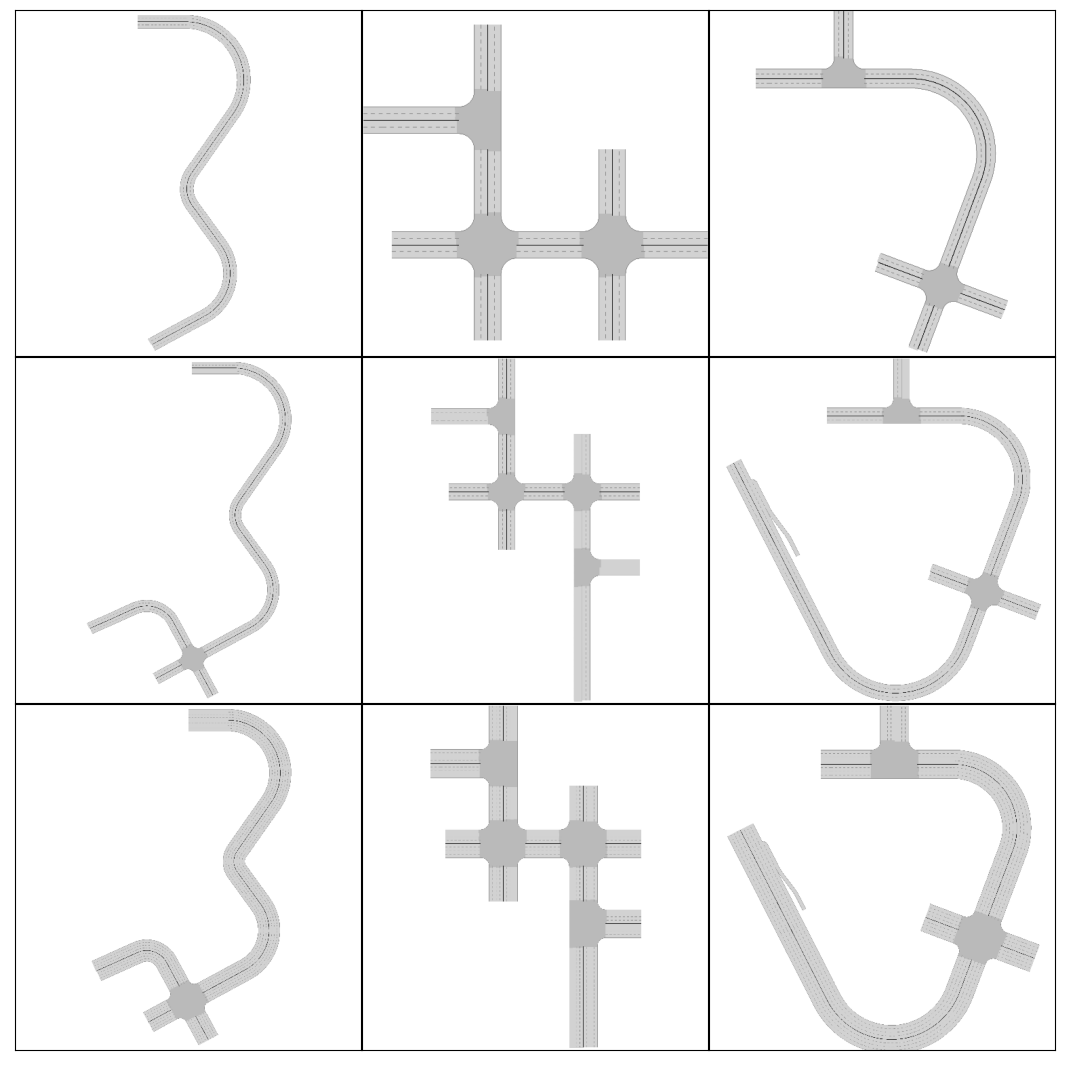

In [7]:
map_config={BaseMap.GENERATE_TYPE: MapGenerateMethod.BIG_BLOCK_NUM, 
            BaseMap.GENERATE_CONFIG: 3,  # 3 block
            BaseMap.LANE_WIDTH: 3.5,
            BaseMap.LANE_NUM: 2}

fig, axs = plt.subplots(3, 3, figsize=(10, 10), dpi=200)
plt.tight_layout(pad=-3)

for i in range(3):
    if i==0:
        map_config["config"]=3
        env = MetaDriveEnv(dict(num_scenarios=10, map_config=map_config, log_level=logging.WARNING))
    elif i==1:
        map_config["config"]=5
        env = MetaDriveEnv(dict(num_scenarios=10, map_config=map_config, log_level=logging.WARNING))
    elif i==2:
        map_config["config"]=5
        map_config["lane_num"]=4
        env = MetaDriveEnv(dict(num_scenarios=10, map_config=map_config, log_level=logging.WARNING))
    for j in range(3):
        env.reset(seed=j)
        m = draw_top_down_map(env.current_map)
        ax = axs[i][j]
        ax.imshow(m, cmap="bone")
        ax.set_xticks([])
        ax.set_yticks([])
    env.close()
plt.show()

You can also specify the shape of the map with `BaseMap.GENERATE_TYPE=MapGenerateMethod.BLOCK_SEQUENCE`. Block sequence is a string with character selected from the following tables:

<table style="width:100%; border-collapse: collapse;">
    <tr style="background-color: #f2f2f2;">
        <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Block Type</th>
        <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">ID</th>
        <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Block Type</th>
        <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">ID</th>
    </tr>
    <tr>
        <td style="border: 1px solid #ddd; padding: 8px;">Straight</td>
        <td style="border: 1px solid #ddd; padding: 8px;">S</td>
        <td style="border: 1px solid #ddd; padding: 8px;">Circular</td>
        <td style="border: 1px solid #ddd; padding: 8px;">C</td>
    </tr>
        <tr>
        <td style="border: 1px solid #ddd; padding: 8px;">InRamp</td>
        <td style="border: 1px solid #ddd; padding: 8px;">r</td>
        <td style="border: 1px solid #ddd; padding: 8px;">OutRamp</td>
        <td style="border: 1px solid #ddd; padding: 8px;">R</td>
    </tr>
        <tr>
        <td style="border: 1px solid #ddd; padding: 8px;">Roundabout</td>
        <td style="border: 1px solid #ddd; padding: 8px;">O</td>
        <td style="border: 1px solid #ddd; padding: 8px;">Intersection</td>
        <td style="border: 1px solid #ddd; padding: 8px;">X</td>
    </tr>
        <tr>
        <td style="border: 1px solid #ddd; padding: 8px;">Merge</td>
        <td style="border: 1px solid #ddd; padding: 8px;">y</td>
        <td style="border: 1px solid #ddd; padding: 8px;">Split</td>
        <td style="border: 1px solid #ddd; padding: 8px;">Y</td>
    </tr>
        <tr>
        <td style="border: 1px solid #ddd; padding: 8px;">Tollgate</td>
        <td style="border: 1px solid #ddd; padding: 8px;">$</td>
        <td style="border: 1px solid #ddd; padding: 8px;">Parking lot</td>
        <td style="border: 1px solid #ddd; padding: 8px;">P</td>
    </tr>
        </tr>
        <tr>
        <td style="border: 1px solid #ddd; padding: 8px;">TInterection</td>
        <td style="border: 1px solid #ddd; padding: 8px;">T</td>
        <td style="border: 1px solid #ddd; padding: 8px;">Fork</td>
        <td style="border: 1px solid #ddd; padding: 8px;">WIP</td>
    </tr>
</table>


The number of block equals to the length of the string to specify the block sequence. The following example shows how to generate maps with a fixed block sequence. 

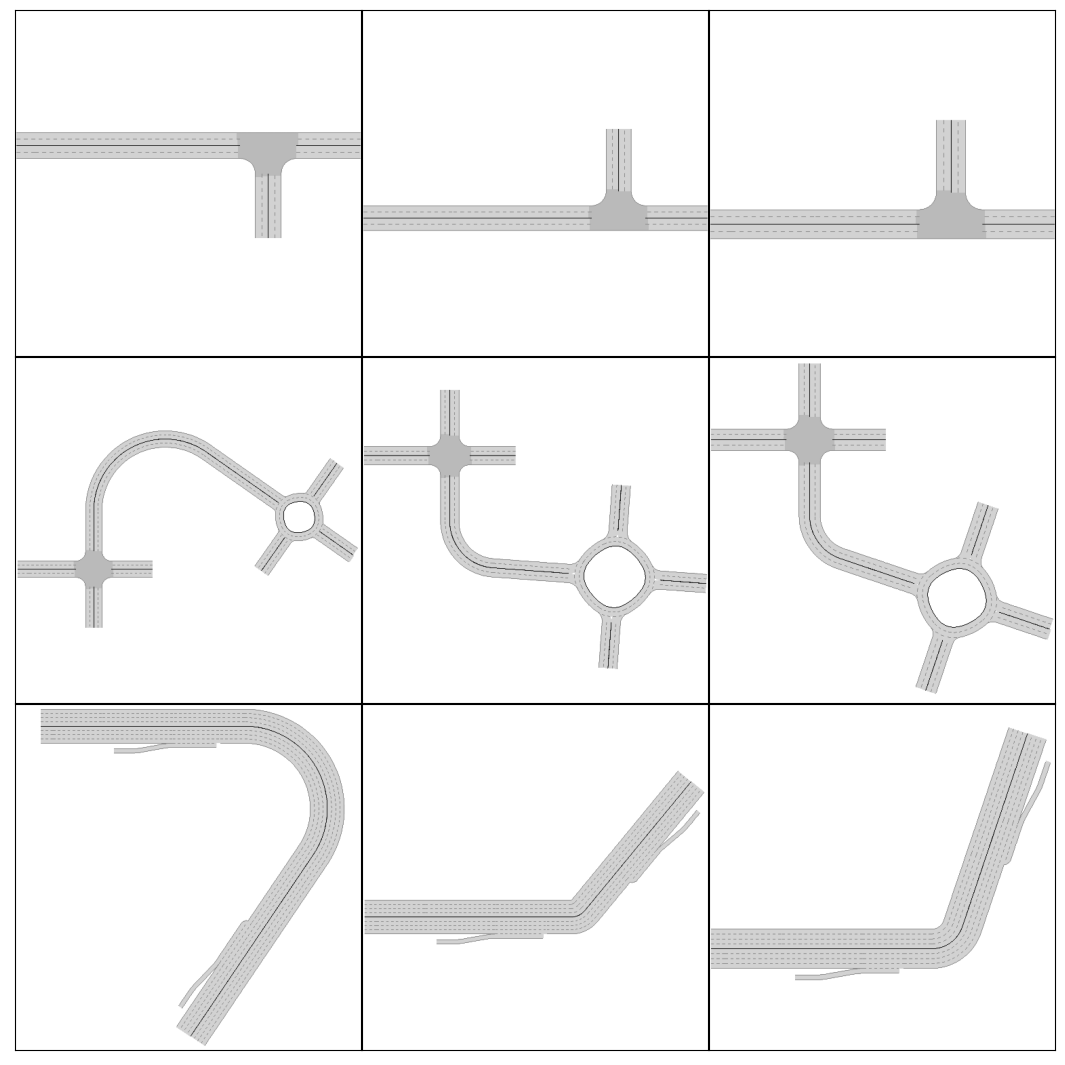

In [8]:
map_config={BaseMap.GENERATE_TYPE: MapGenerateMethod.BIG_BLOCK_SEQUENCE, 
            BaseMap.GENERATE_CONFIG: "XOS",  # 3 block
            BaseMap.LANE_WIDTH: 3.5,
            BaseMap.LANE_NUM: 2}

fig, axs = plt.subplots(3, 3, figsize=(10, 10), dpi=200)
plt.tight_layout(pad=-3)

for i in range(3):
    if i==0:
        map_config["config"]="ST"
        env = MetaDriveEnv(dict(num_scenarios=10, map_config=map_config, log_level=logging.WARNING))
    elif i==1:
        map_config["config"]="XCO"
        env = MetaDriveEnv(dict(num_scenarios=10, map_config=map_config, log_level=logging.WARNING))
    elif i==2:
        map_config["config"]="rCR"
        map_config["lane_num"]=4
        env = MetaDriveEnv(dict(num_scenarios=10, map_config=map_config, log_level=logging.CRITICAL))
    for j in range(3):
        env.reset(seed=j)
        m = draw_top_down_map(env.current_map)
        ax = axs[i][j]
        ax.imshow(m, cmap="bone")
        ax.set_xticks([])
        ax.set_yticks([])
    env.close()
plt.show()

If you only want to change the number and width of lanes, you don't need to set the complex `map_config`. You can use `map` to quickly configure it. User can set a string or int as the value to generate map in an easier way. For example, `config["map"] = 3` means generating a map containing 3 blocks, while `config["map"] = "SCrRX"` means the first block is Straight, and the following blocks are Circular, InRamp, OutRamp and Intersection. The character here are the unique ID of different types of blocks as shown in the table above. 
In a nutshell, if the value of `map` is a number, the map generation method would be `BIG_BLOCK_NUM`. If the value is a string, the map generation method would be `BIG_BLOCK_SEQUENCE`.

In the following example, maps in the first row are composed with 5 blocks, while the maps in the second row are all composed with a roundabout and a curve road.

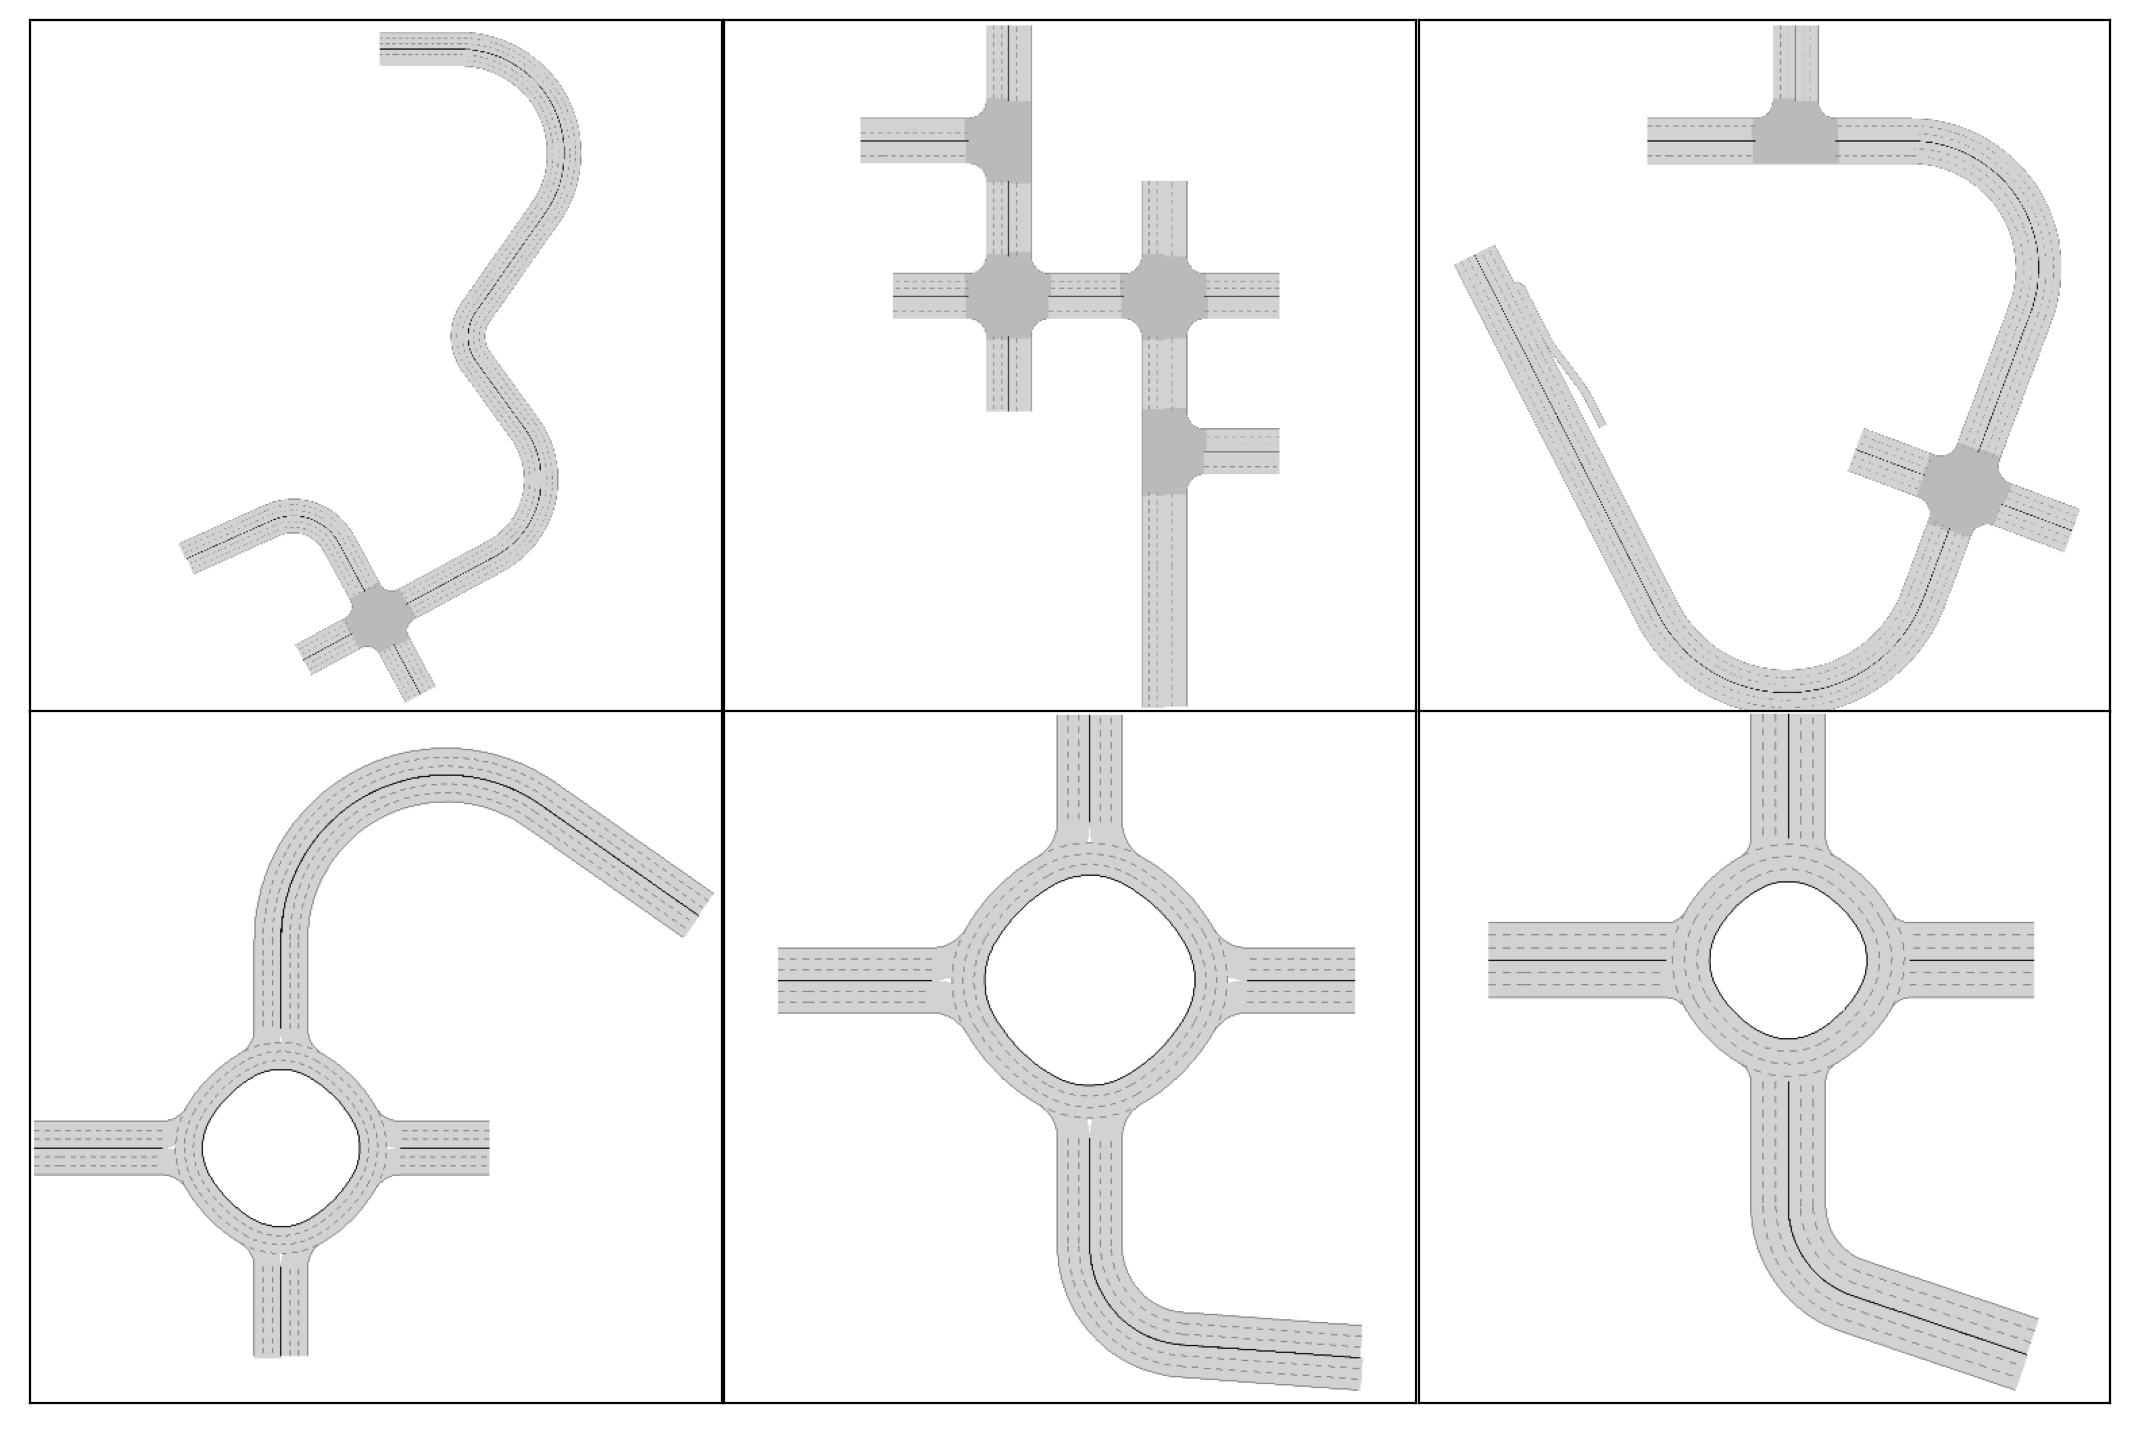

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6.5), dpi=200)
plt.tight_layout(pad=-3)

for i in range(2):
    if i==0:
        env = MetaDriveEnv(dict(num_scenarios=10, map=5, log_level=logging.WARNING))
    elif i==1:
        map_config["config"]="XCO"
        env = MetaDriveEnv(dict(num_scenarios=10, map="OC", log_level=logging.WARNING))
    for j in range(3):
        env.reset(seed=j)
        m = draw_top_down_map(env.current_map)
        ax = axs[i][j]
        ax.imshow(m, cmap="bone")
        ax.set_xticks([])
        ax.set_yticks([])
    env.close()
plt.show()

## VaryingDynamics Environment
Actually, we provide an upgraded version for generalization environment with full PG functionality and can additionally randomize the dynamics of ego vehicle.
The environment is called `VaryingDynamicsEnv` and you can control the `random_dynamics` dict in the config
to adjust the randomizing range of specific dynamics parameters.
In the below example (which is also the default config), we randomize the dynamics of vehicle to the lowest and highest limit we recommended.

In [ ]:
from metadrive.envs.varying_dynamics_env import VaryingDynamicsEnv
from metadrive.component.vehicle.vehicle_type import vehicle_type
import tqdm
import logging

training_env = VaryingDynamicsEnv(dict(
        num_scenarios=1000,  
        
        # Stop randomizing them
        # random_lane_width=True,
        # random_agent_model=True,
        # random_lane_num=True
    
        # We will sample each parameter from (min_value, max_value)
        # You can set it to None to stop randomizing the parameter.
        random_dynamics=dict(
            max_engine_force=(100, 3000),
            max_brake_force=(20, 600),
            wheel_friction=(0.1, 2.5),
            max_steering=(10, 80),  # The maximum steering angle if action = +-1
            mass=(300, 3000)
        ),
        log_level=logging.WARNING
    ))

In [41]:
env_seed=1000
lane_nums = set()
lane_widths = set()
vehicle_models = set()
traffic_vehicle_models = set()

# collect statistics
to_collect_set = {k: set() for k in ["max_engine_force", 
                                     "max_brake_force", 
                                     "wheel_friction", 
                                     "max_steering", 
                                     "mass"]}

maps_to_sample = 50
end_seed = training_env.config["start_seed"] + maps_to_sample
for env_seed in range(training_env.config["start_seed"], end_seed):
    
    # use `seed` argument to choose which scenario to run
    training_env.reset(seed=env_seed)
    lane_nums.add(training_env.current_map.config["lane_num"]) 
    lane_widths.add(training_env.current_map.config["lane_width"])
    vehicle_models.add(training_env.agent.__class__.__name__)
    traffic_models = set([obj.__class__ for obj in training_env.engine.traffic_manager.spawned_objects.values()])
    traffic_vehicle_models = traffic_vehicle_models.union(traffic_models)
    assert vehicle_type[training_env.agent.config["vehicle_model"]] is training_env.agent.__class__
    
    # collect more
    for k, v in to_collect_set.items():
        v.add(training_env.agent.config[k])
    
training_env.close()

print("Number of lanes in {} maps are: {}".format(maps_to_sample, lane_nums))
print("{} maps have {} different widths".format(maps_to_sample, len(lane_widths)))
print("The policy is learning to drive vehicles with {} different dyamics".format(len(to_collect_set["wheel_friction"])))

assert all([len(s)==50 for s in to_collect_set.values()])
assert lane_nums == {3}
assert len(lane_widths) == 1
assert vehicle_models == set([vehicle_type["varying_dynamics"].__name__])
assert len(traffic_vehicle_models) == 4

Number of lanes in 50 maps are: {3}
50 maps have 1 different widths
The policy is learning to drive vehicles with 50 different dyamics


### Wheel Friction Example

In the very early stage of MetaDrive, we have experimented randomizing the `wheel_friction` in the training environment.
We find that `wheel_friction > 1.2` makes little impact to the performance. So you can try a training environment
with `wheel_friction in [1.0, 1.4)` and test the trained agent in `wheel_friction in [0.6, 1.0)`.
The training environment is significantly easier than the test environment.
We are expecting that the agent trained in less training scenarios will perform poorly in the test environment.
The following example shows two episode with different `wheel_friction`. It is obvious that the car with high `wheel_friction` can pass the curve roads, while the car with low `wheel_friction` fails.

In [13]:
from metadrive.policy.idm_policy import IDMPolicy
from metadrive.envs.varying_dynamics_env import VaryingDynamicsEnv
import pygame
import matplotlib.pyplot as plt
from metadrive.utils.doc_utils import generate_gif
import cv2
from IPython.display import Image


def run_env(friction):
    env = VaryingDynamicsEnv(dict(num_scenarios=1, 
                                  traffic_density=0,
                                  agent_policy=IDMPolicy,
                                  map="C",
                                  random_dynamics=dict(wheel_friction=(friction, friction)),
                                  log_level=50))
    env.reset(seed=0)
    try:
        for i in range(1000):
            o,r,d,_,info = env.step([0,0])
            env.render(mode="topdown", 
                       scaling=6, 
                       window=False,
                       camera_position=(70, -60), 
                       screen_size=(700, 1000),
                       screen_record=True,
                       draw_target_vehicle_trajectory=True)
            if d:
                assert info["out_of_road"] if friction < 0.2 else info["arrive_dest"]
                break
        frames=env.top_down_renderer.screen_frames
    finally:
        env.close()
    return frames

# draw
f_1=run_env(0.1)
f_2=run_env(1.2)
frames = []
for i in range(len(f_2)):
    frames.append(cv2.hconcat([f_1[min(i, len(f_1)-1)], f_2[i]]))
generate_gif(frames)

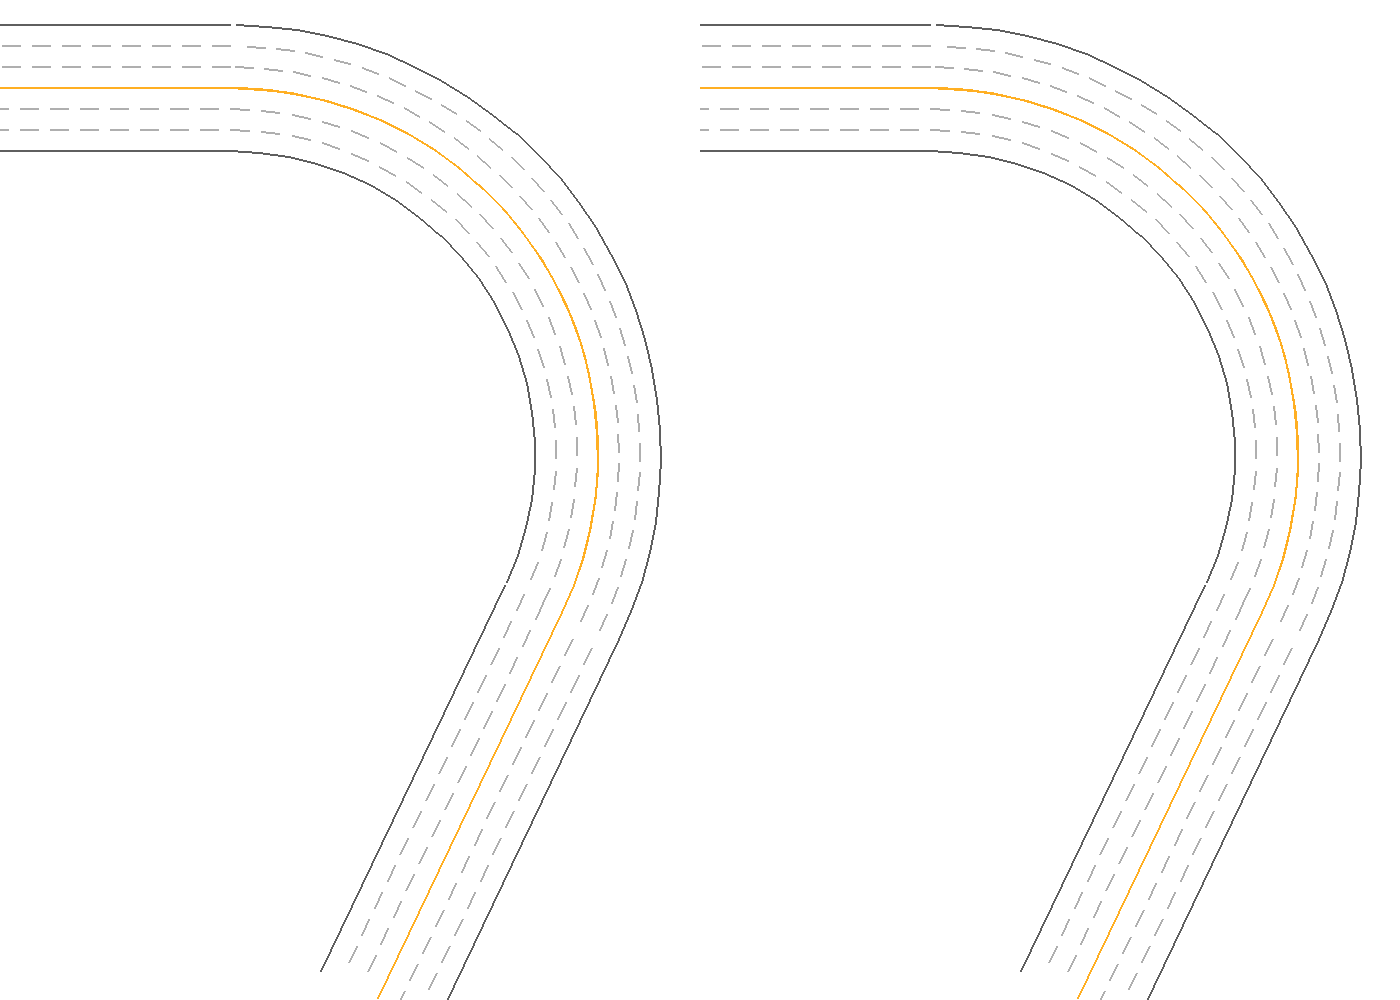

In [14]:
Image(open("demo.gif", "rb").read())

### Termination
The termination or done function defines when the `tm` from `_,_,tm,_,_ = env.step()` should `True`. In the example above, you will find the scenario ends up with collision. That is because we defined that *when crash happens, the episode should end* in `env.done_function`. This all environments should have this function. Besides the official done function, users are encouraged to design their own `done_function` as well. It should be something like:

In [1]:
from metadrive.utils.doc_utils import print_source
from metadrive import MetaDriveEnv
print_source(MetaDriveEnv.done_function)

def done_function(self, vehicle_id: str):
    vehicle = self.vehicles[vehicle_id]
    done = False
    max_step = self.config["horizon"] is not None and self.episode_lengths[vehicle_id] >= self.config["horizon"]
    done_info = {
        TerminationState.CRASH_VEHICLE: vehicle.crash_vehicle,
        TerminationState.CRASH_OBJECT: vehicle.crash_object,
        TerminationState.CRASH_BUILDING: vehicle.crash_building,
        TerminationState.CRASH_HUMAN: vehicle.crash_human,
        TerminationState.CRASH_SIDEWALK: vehicle.crash_sidewalk,
        TerminationState.OUT_OF_ROAD: self._is_out_of_road(vehicle),
        TerminationState.SUCCESS: self._is_arrive_destination(vehicle),
        TerminationState.MAX_STEP: max_step,
        TerminationState.ENV_SEED: self.current_seed,
        # TerminationState.CURRENT_BLOCK: self.agent.navigation.current_road.block_ID(),
        # crash_vehicle=False, crash_object=False, crash_building=False, out_of_road=False, arrive_dest=False,
    }

    # for 

This is the done function of `MetaDriveEnv`. There are several config can turn off/turn on specific done conditions like `crash_vehicle_done` and `crash_object_done`. When they are set to `False`, the crash won't throw a termination signal out. More termination config is available at <a href="reward_cost_done.html#termination-and-truncation">Reward, Cost and Termination</a>.

## Safety Environments



<p align="center"><iframe width="848" height="477" src="https://www.youtube.com/embed/6YNgwxEvYtg" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe></p>


Safety is a major concern for the trial-and-error nature of RL.
As driving itself is a safety-critical application, it is essential to evaluate the constrained optimization methods under the domain of autonomous driving.
We therefore define a new suite of environments to benchmark the **safe exploration** in RL.
As shown in the left panel of the figure above, we randomly display static and movable obstacles in the traffic flow where frequent lane changing and emergence brake are required.

The following script can setup such environment. Same as in generalization environment, you can also specify the number of environment and the start seed to initialize two sets of environments to train and test the RL agents and benchmark their safety generalization. You can experience the safety environment via 

```bash
python -m metadrive.examples.drive_in_safe_metadrive_env
```

### Accident Probability
The environment-specific parameter is `accident_prob`, which controls the density of obstacles on the road. The more traffic objects there are, the more challenging the scenario becomes. Apart from this, all parameters are the same as generalization environment. The accepted parameter for this field ranges from [0, 1.0]. A higher value will make the traffic object more dense. 

In [26]:
from metadrive import SafeMetaDriveEnv

def run_env(density):
    env=SafeMetaDriveEnv(dict(map="CCCCC", accident_prob = density, log_level=50))
    env.reset(seed=0)
    obj_num=len(env.engine.object_manager.spawned_objects)
    print("There are {} traffic objects on the map with accident_prob={}".format(obj_num,density))
    env.close()

run_env(0.1)
run_env(1)


There are 12 traffic objects on the map with accident_prob=0.1
There are 27 traffic objects on the map with accident_prob=1


### Termination and Cost
Different from the generalization task, we set `crash_vehicle_done=False` and `crash_object_done=False` and thus do not terminate the agent if a collision with those obstacles and traffic vehicles happens.
Instead, we allow agent to continue driving but flag the crash with a cost. The concrete value of the cost when collision happens is defined by `out_of_road_cost`, `crash_vehicle_cost`, and `crash_object_cost`.
Thus as safe exploration task, the learning agent is required to balance the reward and the cost to solve the constrained optimization problem.
In the following example, we put a cone in front of the car.
When the car collides with the cone, the cost will be recorded in the info dict.

In [ ]:
from metadrive import SafeMetaDriveEnv
from metadrive.component.static_object.traffic_object import TrafficCone
import os

try:
    env=SafeMetaDriveEnv(dict(crash_object_cost=-5, 
                              random_spawn_lane_index=False,
                              # use 3D renderer
                              use_render=not os.getenv('TEST_DOC'))) 
    env.reset(seed=0)
    cone=env.engine.spawn_object(TrafficCone, position=[20, 7], heading_theta=0)
    for _ in range(100):
        o,r,d,_,info = env.step([0, 1])
        if env.agent.crash_object:
            assert info["cost"] == -5
            break
    env.engine.clear_objects([cone.id])
finally:
    env.close()

## Multi-agent Environments
<video style="display:block; width:100%; height:auto; text-align: center;" autoplay="autoplay" muted="" loop="loop" playsinline="" id="marl_video">
<source src="https://raw.githubusercontent.com/decisionforce/archive/master/CoPO/copo_env.mp4" type="video/mp4">
</video>

As shown in the above figure,
we develop a set of environments to evaluate MARL methods for simulating traffic flow.
The descriptions and typical settings of the six traffic environments are as follows:

1. **Roundabout**: A four-way roundabout with two lanes. 40 vehicles spawn during environment reset. This environment includes merge and split junctions.
2. **Intersection**: An unprotected four-way intersection allowing bi-directional traffic as well as U-turns. Negotiation and social behaviors are expected to solve this environment. We initialize 30 vehicles.
3. **Tollgate**: Tollgate includes narrow roads to spawn agents and ample space in the middle with multiple tollgates. The tollgates create static obstacles where the crashing is prohibited. We force agent to stop at the middle of tollgate for 3s. The agent will fail if they exit the tollgate before being allowed to pass. 40 vehicles are initialized. Complex behaviors such as deceleration and queuing are expected. Additional states such as whether vehicle is in tollgate and whether the tollgate is blocked are given.
4. **Bottleneck**: Complementary to Tollgate, Bottleneck contains a narrow bottleneck lane in the middle that forces the vehicles to yield to others. We initialize 20 vehicles.
5. **Parking Lot**: A compact environment with 8 parking slots. Spawn points are scattered in both parking lots or in external roads. 10 vehicles spawn initially and need to navigate toward external roads or enter parking lots. In this environment, we allow agents to back their cars to spare space for others.  Maneuvering and yielding are the key to solve this task.
6. **PGMA** (Procedural Generation Multi-Agent environment): We reuse the procedurally generated scenarios in the generalization environment and replaces the traffic vehicles by controllable target vehicles. These environments contain rich interactions between agents and complex road structures. This multi-agent environment introduces new challenge under the setting of mixed motive RL. Each constituent agent in this traffic system is self-interested and the relationship between agents is constantly changing.

You can try to drive a vehicle in Multi-agent environment through this example:
```bash
# args:
# --env: roundabout, intersection, tollgate, bottleneck, parkinglot, pgma
# --topdown
python -m metadrive.examples.drive_in_multi_agent_env --env pgma
```

For using these environments in your code, the following script initialize arbitrary Multi-agent environment and visualizes these environments are as follows:

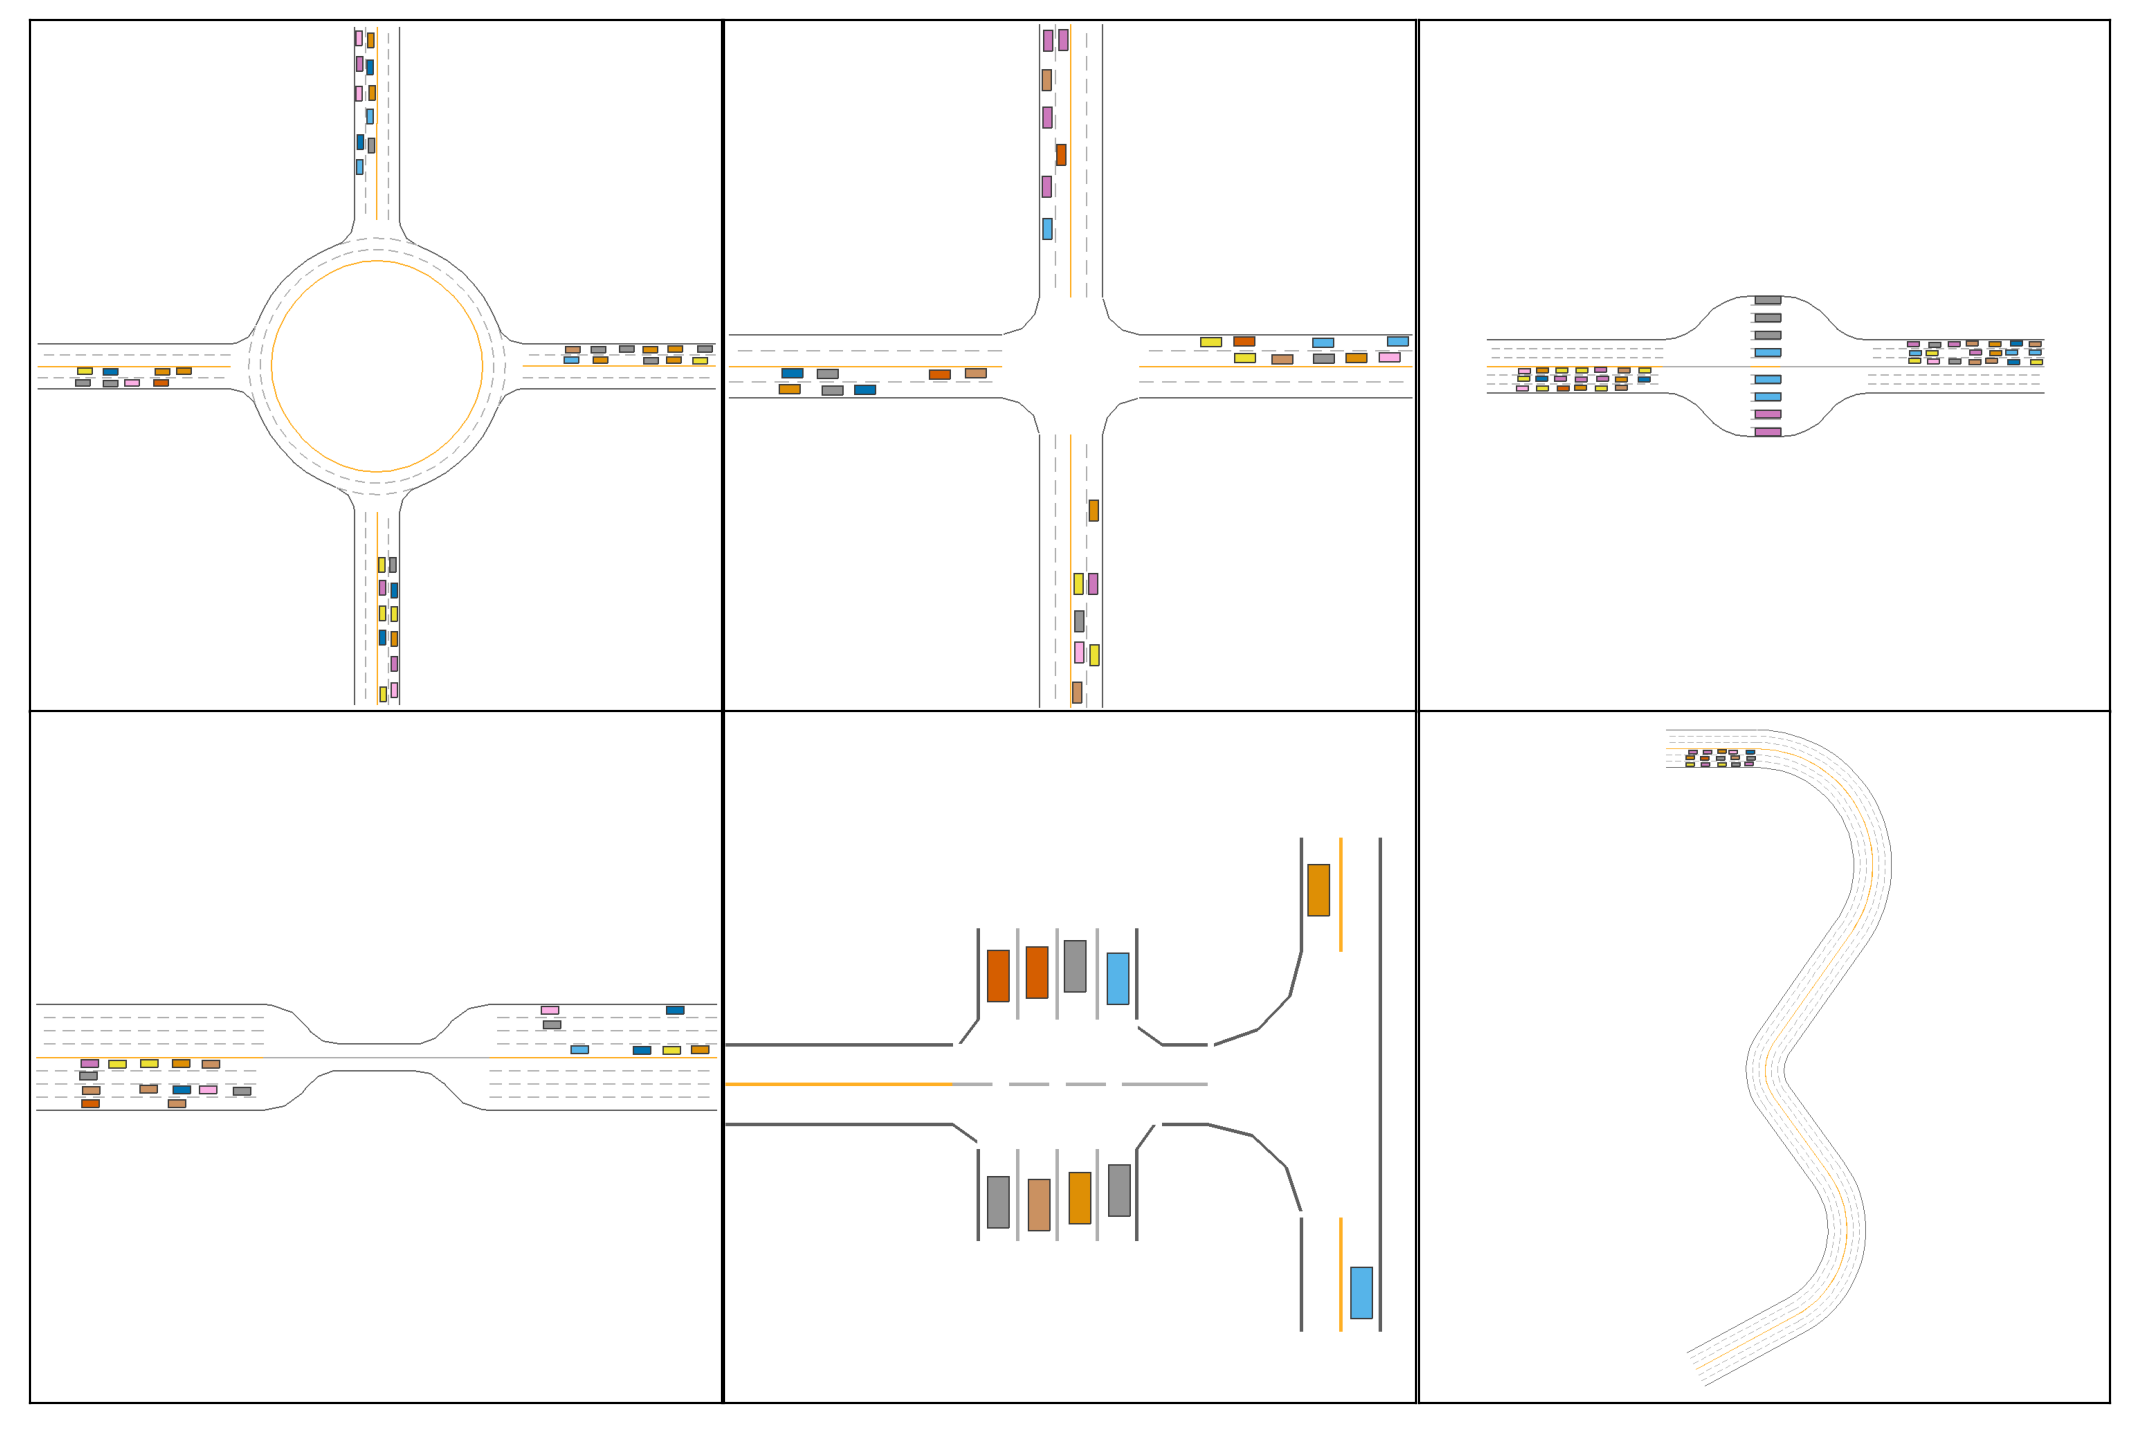

In [12]:
import matplotlib.pyplot as plt
from metadrive import (
    MultiAgentMetaDrive,
    MultiAgentTollgateEnv,
    MultiAgentBottleneckEnv,
    MultiAgentIntersectionEnv,
    MultiAgentRoundaboutEnv,
    MultiAgentParkingLotEnv
)

env_classes = dict(
    roundabout=MultiAgentRoundaboutEnv,
    intersection=MultiAgentIntersectionEnv,
    tollgate=MultiAgentTollgateEnv,
    bottleneck=MultiAgentBottleneckEnv,
    parkinglot=MultiAgentParkingLotEnv,
    pgma=MultiAgentMetaDrive
)

fig, axs = plt.subplots(2, 3, figsize=(10, 6.5), dpi=200)
plt.tight_layout(pad=-3)

for i in range(2):
    for j in range(3):
        env = list(env_classes.values())[i*3+j]({"log_level":50})
        env.reset(seed=0)
        m = env.render(mode="topdown", 
                       # get the overview of the scene
                       film_size = (1000, 1000),
                       screen_size = (1000, 1000),
                       # set camer to map center
                       camera_position=env.current_map.get_center_point(), 
                       # auto determine the number of pixels for 1 meter 
                       scaling=None,
                       # do not pop window
                       window=False)
        ax = axs[i][j]
        ax.imshow(m, cmap="bone")
        ax.set_xticks([])
        ax.set_yticks([])
        env.close()
plt.show()


### Number of Agents
The more agents there are, the harder the MARL task is.
You can change the number of agents in the environment with the value of field `num_agents` in the config dict. 
Note there is a upper bound for the number of agents that can be accommodated in each environment.

### Respawn
Besides, in Multi-agent environment, the controllable target vehicles consistently respawn in the scene if old target vehicles are terminated.
If you wish to disable the respawning mechanism in MARL, set the config `allow_respawn = False`. In this case, the environmental episode will terminate if no active vehicles are in the scene.

### MARL Termination
In Multi-agent environment, the termination criterion for each vehicle is identical to that in single-agent environment.
Like the `SafeMetaDriveEnv`, we explicitly add two config to adjust the termination processing in MARL: `crash_done = True` and `out_of_road_done = True`.
They denote whether to terminate the agent episode if crash / out of road happens.
Like single-agent environment, config `horizon = 1000` can be used in MARL environments as well to limit the length of *environmental episode*.
The environmental episode has a **minimal length** of `horizon` steps and the environment will stop spawning new target vehicles if this horizon is exceeded.
Also, the agent which exists more than `horizon` steps will be terminated as well.
You can adjust them to change the termination condition or compose your own `done_function`.

There is another key called `delay_done` whose unit is `substep`. It denotes the terminated agent won't be recycled until `delay_done` substeps are taken. `decision_repeat` defines how many substeps will be executed in each `env.step()`. The default value is set to 5. The simulation time will progress `physics_world_step_size` when executing one `substep`. By default, the `physics_world_step_size` is `0.02`. Consequently, if we want to recycle the vehicle 10 seconds later after it is terminated, we can set `delay_done` as 50.

Feel free to change the value of these keys in the following intersection example to experience these features. 

In [ ]:
from metadrive import  MultiAgentIntersectionEnv

env = MultiAgentIntersectionEnv(dict(num_agents=40,
                                     delay_done=5, 
#                                      allow_respawn=False
                                     ))
o,_=env.reset(seed=0)
try:
    while True:
        last_o=o
        o,r,tm,_,i=env.step({agent_id: [0, 1] for agent_id in env.agents.keys()})
        m = env.render(mode="topdown", 
                   film_size = (1000, 1000),
                   screen_size = (1000, 1000),
                   camera_position=env.current_map.get_center_point(), 
                   scaling=None)
        if tm["__all__"]:
            break
            
        # for test only
        assert len(env.agents)<=env.config["num_agents"]
        if not env.config["allow_respawn"]:
            assert len(o)<=len(last_o)
finally:
    env.close()

## Real-world Environment

<video style="display:block; width:100%; height:auto; text-align: center;" autoplay="autoplay" muted="" loop="loop" playsinline="" id="real_env_video">
<source 
src="https://metadriverse.github.io/assets/scenarionet/teaser_video.mp4"
type="video/mp4">
</video>

The real-world environments are built from real-world driving datasets collected by Waymo, nuPlan, nuScenes, Argoverse and so on. We provide converters for parsing driving data in various format into one unified format. As a result, MetaDrive can reconstruct and simulate the scenarios collected by different data providers, which greatly expands the scenario database. More details about setting up real-world data can be found at [ScenarioNet](https://metadriverse.github.io/scenarionet/).

Once you have built a driving dataset with scenarios described by MetaDrive format, you can launch the simulation for these real-world scenarios. We have included two mini split data from Waymo and nuScenes in MetaDrive asset. The script allows you to drive in real-world environment reconstructed with nuScenes or Waymo data:

```bash
# args:
# Using Waymo data: --waymo 
# Using Topdown renderer --topdown
python -m metadrive.examples.drive_in_real_env
```

For using it in your code, import and use the `ScenarioEnv` and the full config is at [SCENARIO_ENV_CONFIG](https://github.com/metadriverse/metadrive/blob/9a89962e72c709e60d4a5bc19ce5f27d96027401/metadrive/envs/scenario_env.py). The following example shows 3 scenarios from nuScenes mini split. If your machine has OpenGL support, you can launch the 3D renderer as well by `threeD_render=True`.

In [ ]:
from metadrive.engine.asset_loader import AssetLoader
from metadrive.policy.replay_policy import ReplayEgoCarPolicy
from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.utils.doc_utils import generate_gif
from IPython.display import Image, clear_output
import cv2

# turn on this to enable 3D render. It only works when you have a screen
threeD_render=False 
# Use the built-in datasets with simulator
nuscenes_data=AssetLoader.file_path(AssetLoader.asset_path, "nuscenes", unix_style=False) 

env = ScenarioEnv(
    {
        "reactive_traffic": False,
        "use_render": threeD_render,
        "agent_policy": ReplayEgoCarPolicy,
        "data_directory": nuscenes_data,
        "num_scenarios": 3,
    }
)

try:
    scenarios={}
    for seed in range(3):
        print("\nSimulate Scenario: {}".format(seed))
        o, _ = env.reset(seed=seed)
        semantic_map = seed == 1
        for i in range(1, 100000):
            o, r, tm, tc, info = env.step([1.0, 0.])
            env.render(mode="top_down", 
                       window=False,
                       screen_record=True,
                       text={"Index": seed,
                             "semantic_map": semantic_map},
                       screen_size=(500, 500),
                       semantic_map=semantic_map) # semantic topdown
            if info["replay_done"]:
                break
        scenarios[seed]=env.top_down_renderer.screen_frames
finally:
    env.close()

# make gif for three scenarios
frames=[]
min_len=min([len(scenario) for scenario in scenarios.values()])
for i in range(min_len):
    frames.append(cv2.hconcat([scenarios[s][i] for s in range(3)]))
    
clear_output()
generate_gif(frames)
Image(open("demo.gif", "rb").read())

### Specifying Dataset
`data_directory` is used to specify the path to the dataset. Similar to `start_seed` used in single-agent environment, `start_scenario_index` and `num_scenarios` can be used to split a batch of data from the full dataset, so the scenarios whose index ranges in [`start_scenario_index`, `start_scenario_index` + `num_scenarios`] will be selected. Subsequently, `env.reset(seed=index)` can launch a specific scenario in the simulation. If you want to traverse all scenarios without specifying `seed` in `env.reset()`, you can set `sequential_seed=True` and each time when `env.reset()` is called, the engine will move the scenario to the scenaior whose index is `current_scenario_index + 1`.

### Reactive Traffic
If the ego car is not trained to exactly follow the logged trajectories, traffic vehicles have to be reactive. Otherwise, rear-end collision with the ego car may happen, which is unreasonable.
In the following example, the green car is going to stop instead of keeping moving forward, while the car behind it can not realize it and thus collide with it. By setting `reactive_traffic=True`, at the same frame, we can see the car behind the ego car reacts to the ego car's behavior and stops.

In [6]:
import numpy as np
from metadrive.engine.asset_loader import AssetLoader
from metadrive.policy.replay_policy import ReplayEgoCarPolicy
from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.utils.doc_utils import generate_gif
import cv2
from IPython.display import Image

nuscenes_data =  AssetLoader.file_path(AssetLoader.asset_path, "nuscenes-mini", unix_style=False)

def run_real_env(reactive):
    env = ScenarioEnv(
        {
            "reactive_traffic": reactive,
            "data_directory": nuscenes_data,
            "start_scenario_index":9, # use scenario #6
            "num_scenarios": 1,
            "crash_vehicle_done": True,
            "log_level": 50,
        }
    )
    try:
        o, _ = env.reset(seed=9) # start simulation for senario #6
        for i in range(1, 150):
            o, r, tm, tc, info = env.step([.0, -1])
            env.render(mode="top_down", 
                       window=False,
                       screen_record=True, 
                       camera_position=(0,0),
                       screen_size=(500, 400))
        frames=env.top_down_renderer.screen_frames
    finally:
        env.close()
    return frames

# visualization
f_1=run_real_env(False)
f_2=run_real_env(True)
frames = []
for i in range(len(f_1)):
    frames.append(cv2.hconcat([f_1[i], f_2[i]]))
generate_gif(frames)

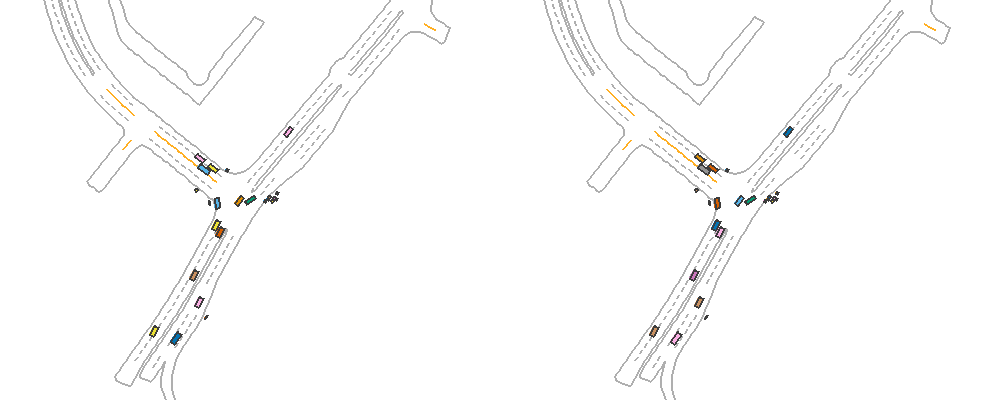

In [7]:
Image(open("demo.gif", "rb").read())

## Customization
We are developing new environments for benchmarking novel and challenging RL tasks! Any idea on the design of new tasks are welcomed!

However, you may want to do development with MetaDrive and build your own environments from scratch. To this end, you have to be familiar with some basic concepts of MetaDrive and how the simulation works. Please refer to the content under **Concepts and Customiaiton** and the section [Developing Environments](new_env.ipynb).



## GymWrapper
Some legacy training frameworks may use the `openai.gym` interface whose `step()` function returns `obs`, `reward`, `termination`, and `info`. For making MetaDrive compatible with these training code, we provide an official wrapper for **all** environments of MetaDrive. The wrapped environment will have an `openai.gym` style APIs. Also, you can access all properties and methods of wrapped env using the same syntax. For example, we can still access the ego car via `env.agent`, even if the env is wrapped on top of `MetaDriveEnv`. 

[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.1.2
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): None
[INFO] Assets version: 0.4.1.2
[INFO] Known Pipes: glxGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 1


Vehicle id: 4587b581-8c65-415f-beaf-daf861dc4f0c


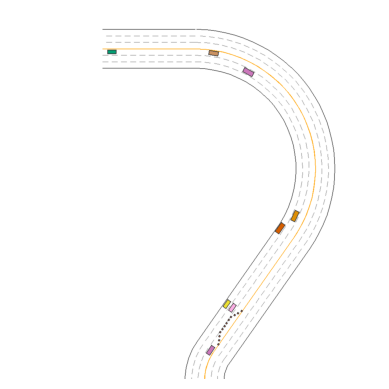

In [7]:
from metadrive.envs.gym_wrapper import createGymWrapper
from metadrive.envs.metadrive_env import MetaDriveEnv
import matplotlib.pyplot as plt

env_config = {"accident_prob": 1.0}
gym_env = createGymWrapper(MetaDriveEnv)(env_config)
try:
    o = gym_env.reset()
    o,r,d,i = gym_env.step([0,0])
    assert gym_env.config["accident_prob"] == 1.0
    print("Vehicle id:", gym_env.agent.id)
    ret=gym_env.render(mode="topdown", 
                       window=False,
                       camera_position=(50, -70))
finally:
    gym_env.close()
    
plt.axis('off')    
plt.imshow(ret)

In [ ]:
from metadrive.engine.asset_loader import AssetLoader
from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.envs.gym_wrapper import createGymWrapper
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
import numpy as np

# 加载 nuScenes 数据
nuscenes_data = AssetLoader.file_path(AssetLoader.asset_path, "nuscenes", unix_style=False)

# 创建环境工厂函数（用于多进程）
def make_env():
    def _init():
        env = ScenarioEnv({
            "data_directory": nuscenes_data,
            "num_scenarios": 20,  # 使用前20个场景进行训练
            "start_scenario_index": 0,
            "crash_vehicle_done": True,
            "log_level": 50,  # WARNING level，减少输出
            "reactive_traffic": True,  # 打开反应式交通
        })
        # 包装为 Gym 接口
        return createGymWrapper(ScenarioEnv)(env.config)
    return _init

# 方法1：单进程训练（用于调试）
def train_single_process():
    env = ScenarioEnv({
        "data_directory": nuscenes_data,
        "num_scenarios": 5,
        "start_scenario_index": 0,
        "crash_vehicle_done": True,
        "log_level": 50,
        "reactive_traffic": True,
    })
    
    # 包装为 Gym 接口
    gym_env = createGymWrapper(ScenarioEnv)(env.config)
    
    try:
        # 创建 PPO 模型
        model = PPO(
            "MlpPolicy",
            gym_env,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            verbose=1,
            tensorboard_log="./ppo_tensorboard/"
        )
        
        # 训练模型
        model.learn(total_timesteps=10000)
        
        # 保存模型
        model.save("ppo_nuscenes_model")
        print("Model saved as ppo_nuscenes_model")
        
    finally:
        gym_env.close()

# 方法2：多进程并行训练（推荐，更快）
def train_multiprocess():
    # 创建并行环境
    env = SubprocVecEnv([make_env for _ in range(4)])  # 4 个并行进程
    
    try:
        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            verbose=1,
            tensorboard_log="./ppo_tensorboard/"
        )
        
        model.learn(total_timesteps=50000)
        model.save("ppo_nuscenes_multiprocess")
        print("Multi-process model saved")
        
    finally:
        env.close()

# 测试已训练的模型
def test_trained_model(model_path):
    env = ScenarioEnv({
        "data_directory": nuscenes_data,
        "num_scenarios": 5,
        "start_scenario_index": 20,  # 使用不同的场景进行测试
        "crash_vehicle_done": True,
        "log_level": 50,
        "reactive_traffic": True,
    })
    
    gym_env = createGymWrapper(ScenarioEnv)(env.config)
    
    try:
        model = PPO.load(model_path)
        
        obs = gym_env.reset()
        episode_rewards = []
        episode_reward = 0
        
        for _ in range(1000):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = gym_env.step(action)
            episode_reward += reward
            
            if done:
                episode_rewards.append(episode_reward)
                obs = gym_env.reset()
                episode_reward = 0
        
        print(f"Test episodes: {len(episode_rewards)}")
        print(f"Mean reward: {np.mean(episode_rewards):.3f}")
        print(f"Std reward: {np.std(episode_rewards):.3f}")
        
    finally:
        gym_env.close()

# 执行训练（注意：这会花费较长时间，仅作示例）
# train_single_process()
# 或
# train_multiprocess()

# 测试（取消注释以运行）
# test_trained_model("ppo_nuscenes_model")

In [ ]:
from ray import air, tune
from ray.rllib.algorithms.ppo import PPO as RayPPO
from ray.rllib.algorithms.callbacks import DefaultCallbacks
from metadrive.envs.gym_wrapper import createGymWrapper

# 自定义回调用于评估
class EvaluationCallback(DefaultCallbacks):
    def on_train_result(self, algorithm, result, **info):
        # 可以在训练过程中进行自定义评估
        if result["training_iteration"] % 10 == 0:
            print(f"Iteration {result['training_iteration']}: "
                  f"mean_episode_reward={result.get('env_runners', {}).get('episode_reward_mean', 0):.2f}")

def train_with_rllib():
    """使用 Ray RLlib 进行分布式 PPO 训练"""
    
    # 创建训练环境配置
    train_env_config = {
        "data_directory": AssetLoader.file_path(AssetLoader.asset_path, "nuscenes", unix_style=False),
        "num_scenarios": 30,
        "start_scenario_index": 0,
        "crash_vehicle_done": True,
        "reactive_traffic": True,
        "log_level": 50,
    }
    
    # PPO 算法配置
    ppo_config = {
        "env": "metadrive_scenario_env",  # 需要注册这个环境
        "env_config": train_env_config,
        
        # 框架
        "framework": "torch",
        
        # 学习率和优化
        "lr": 3e-4,
        "gamma": 0.99,
        "lambda": 0.95,
        "clip_param": 0.2,
        "entropy_coeff": 0.01,
        
        # 数据收集
        "num_rollout_workers": 8,  # 使用 8 个工作进程
        "num_gpus": 1,  # 主进程使用 1 个 GPU
        "num_gpus_per_worker": 0.25,  # 每个工作进程使用 0.25 GPU（4个工作进程共享1个GPU）
        "num_envs_per_worker": 1,
        
        # 训练
        "train_batch_size": 4096,
        "sgd_minibatch_size": 128,
        "num_sgd_iter": 20,
        "horizon": 1000,
        "rollout_fragment_length": 200,
        
        # 模型
        "model": {
            "fcnet_hiddens": [256, 256],
            "fcnet_activation": "relu",
        },
        
        # 回调
        "callbacks": EvaluationCallback,
    }
    
    # 注册环境
    from ray.tune import register_env
    def env_creator(config):
        return createGymWrapper(ScenarioEnv)(config)
    
    register_env("metadrive_scenario_env", env_creator)
    
    # 创建 PPO 算法实例
    algo = RayPPO(config=ppo_config)
    
    # 训练循环
    for i in range(100):
        result = algo.train()
        if i % 10 == 0:
            checkpoint = algo.save()
            print(f"Checkpoint saved: {checkpoint}")
    
    # 保存最终模型
    algo.save("./ppo_scenario_final")
    return algo

# 运行 Ray RLlib 训练（注意：这会启动分布式系统）
# algo = train_with_rllib()

In [ ]:
import os
from metadrive.engine.asset_loader import AssetLoader
from metadrive.envs.scenario_env import ScenarioEnv
from metadrive.envs.gym_wrapper import createGymWrapper
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
import numpy as np

class ScenarioRLTrainer:
    """完整的 ScenarioEnv PPO 训练类"""
    
    def __init__(self, data_source="nuscenes", num_train_scenarios=50, num_eval_scenarios=10):
        """
        初始化训练器
        
        Args:
            data_source: 数据源，支持 "nuscenes", "waymo" 等
            num_train_scenarios: 训练场景数
            num_eval_scenarios: 评估场景数
        """
        self.data_source = data_source
        self.num_train_scenarios = num_train_scenarios
        self.num_eval_scenarios = num_eval_scenarios
        
        # 加载数据路径
        if data_source == "nuscenes":
            self.data_dir = AssetLoader.file_path(AssetLoader.asset_path, "nuscenes", unix_style=False)
        else:
            raise ValueError(f"Unsupported data source: {data_source}")
        
        # 创建输出目录
        self.output_dir = f"./{data_source}_training"
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(f"{self.output_dir}/models", exist_ok=True)
        os.makedirs(f"{self.output_dir}/logs", exist_ok=True)
        
    def create_train_env(self):
        """创建训练环境"""
        env = ScenarioEnv({
            "data_directory": self.data_dir,
            "num_scenarios": self.num_train_scenarios,
            "start_scenario_index": 0,
            "crash_vehicle_done": True,
            "reactive_traffic": True,
            "log_level": 50,
        })
        return createGymWrapper(ScenarioEnv)(env.config)
    
    def create_eval_env(self):
        """创建评估环境（使用不同的场景）"""
        env = ScenarioEnv({
            "data_directory": self.data_dir,
            "num_scenarios": self.num_eval_scenarios,
            "start_scenario_index": self.num_train_scenarios,  # 使用不同的场景
            "crash_vehicle_done": True,
            "reactive_traffic": True,
            "log_level": 50,
        })
        return createGymWrapper(ScenarioEnv)(env.config)
    
    def train(self, total_timesteps=100000, learning_rate=3e-4):
        """
        训练 PPO 模型
        
        Args:
            total_timesteps: 总训练步数
            learning_rate: 学习率
        """
        # 创建环境
        train_env = self.create_train_env()
        eval_env = self.create_eval_env()
        
        try:
            # 创建回调
            checkpoint_callback = CheckpointCallback(
                save_freq=10000,
                save_path=f"{self.output_dir}/models",
                name_prefix="ppo_checkpoint"
            )
            
            eval_callback = EvalCallback(
                eval_env,
                best_model_save_path=f"{self.output_dir}/best_model",
                log_path=f"{self.output_dir}/logs",
                eval_freq=5000,
                deterministic=True,
                render=False
            )
            
            # 创建 PPO 模型
            model = PPO(
                "MlpPolicy",
                train_env,
                learning_rate=learning_rate,
                n_steps=2048,
                batch_size=64,
                n_epochs=10,
                gamma=0.99,
                gae_lambda=0.95,
                clip_range=0.2,
                ent_coef=0.01,
                verbose=1,
                tensorboard_log=f"{self.output_dir}/logs"
            )
            
            # 训练
            print(f"开始训练 PPO 模型...")
            print(f"训练场景数: {self.num_train_scenarios}")
            print(f"评估场景数: {self.num_eval_scenarios}")
            print(f"总训练步数: {total_timesteps}")
            
            model.learn(
                total_timesteps=total_timesteps,
                callback=[checkpoint_callback, eval_callback],
                log_interval=10
            )
            
            # 保存最终模型
            model.save(f"{self.output_dir}/models/ppo_final")
            print(f"模型已保存到 {self.output_dir}/models/ppo_final")
            
            return model
            
        finally:
            train_env.close()
            eval_env.close()
    
    def evaluate(self, model_path, num_episodes=10):
        """
        评估已训练的模型
        
        Args:
            model_path: 模型文件路径
            num_episodes: 评估的回合数
        """
        eval_env = self.create_eval_env()
        
        try:
            model = PPO.load(model_path)
            
            episode_rewards = []
            episode_lengths = []
            
            for ep in range(num_episodes):
                obs = eval_env.reset()
                episode_reward = 0
                episode_length = 0
                
                while True:
                    action, _ = model.predict(obs, deterministic=True)
                    obs, reward, done, info = eval_env.step(action)
                    episode_reward += reward
                    episode_length += 1
                    
                    if done:
                        break
                
                episode_rewards.append(episode_reward)
                episode_lengths.append(episode_length)
                print(f"Episode {ep + 1}: reward={episode_reward:.2f}, length={episode_length}")
            
            # 计算统计信息
            print(f"\n=== 评估结果 ===")
            print(f"平均奖励: {np.mean(episode_rewards):.2f} ± {np.std(episode_rewards):.2f}")
            print(f"平均回合长度: {np.mean(episode_lengths):.1f}")
            print(f"最大奖励: {np.max(episode_rewards):.2f}")
            print(f"最小奖励: {np.min(episode_rewards):.2f}")
            
            return {
                "mean_reward": np.mean(episode_rewards),
                "std_reward": np.std(episode_rewards),
                "episode_rewards": episode_rewards,
                "episode_lengths": episode_lengths
            }
            
        finally:
            eval_env.close()

# 使用示例
if __name__ == "__main__":
    # 创建训练器（使用较小的数据集进行演示）
    trainer = ScenarioRLTrainer(
        data_source="nuscenes",
        num_train_scenarios=10,
        num_eval_scenarios=5
    )
    
    # 训练模型（注意：实际训练需要较长时间）
    # model = trainer.train(total_timesteps=50000, learning_rate=3e-4)
    
    # 评估模型
    # results = trainer.evaluate(f"{trainer.output_dir}/models/ppo_final", num_episodes=5)

In [ ]:
import matplotlib.pyplot as plt
import json

def visualize_training_results(log_dir):
    """
    可视化训练结果
    """
    # 尝试读取 TensorBoard 日志（如果可用）
    print(f"训练日志已保存到: {log_dir}")
    print("可以使用 TensorBoard 查看训练进度:")
    print(f"  tensorboard --logdir={log_dir}")

def quick_test_example():
    """
    快速测试示例 - 验证环境设置是否正确
    """
    try:
        # 加载数据
        from metadrive.engine.asset_loader import AssetLoader
        nuscenes_data = AssetLoader.file_path(AssetLoader.asset_path, "nuscenes", unix_style=False)
        print(f"✓ nuScenes 数据加载成功: {nuscenes_data}")
        
        # 创建环境
        from metadrive.envs.scenario_env import ScenarioEnv
        from metadrive.envs.gym_wrapper import createGymWrapper
        
        env = ScenarioEnv({
            "data_directory": nuscenes_data,
            "num_scenarios": 1,
            "start_scenario_index": 0,
            "crash_vehicle_done": True,
            "log_level": 50,
        })
        gym_env = createGymWrapper(ScenarioEnv)(env.config)
        print("✓ 环境创建成功")
        
        # 测试一个回合
        obs = gym_env.reset()
        for _ in range(50):
            action = gym_env.action_space.sample()  # 随机动作
            obs, reward, done, info = gym_env.step(action)
            if done:
                break
        print("✓ 环境执行成功")
        
        gym_env.close()
        print("\n所有检查通过！环境已准备就绪。")
        return True
        
    except Exception as e:
        print(f"✗ 错误: {e}")
        return False

# 运行快速测试
# quick_test_example()

# 训练完成后查看日志
# visualize_training_results("./nuscenes_training/logs")

## 总结

本章节介绍了如何使用 `ScenarioEnv` 加载真实世界的驾驶数据（如 nuScenes）来训练强化学习模型。主要内容包括：

### 核心要点

1. **环境设置**: 使用 `ScenarioEnv` 加载真实数据，配合 `createGymWrapper` 适配标准的 Gym 接口

2. **训练方法**:
   - **单进程**: 简单快速调试（Stable-Baselines3）
   - **多进程**: 加速训练（SubprocVecEnv）
   - **分布式**: 大规模训练（Ray RLlib）

3. **关键配置**:
   - `reactive_traffic=True`: 启用交通反应，获得更真实的场景
   - `crash_vehicle_done=True`: 碰撞结束回合，实现安全训练
   - `start_scenario_index`: 数据集划分的关键参数

4. **评估策略**:
   - 使用不同的 `start_scenario_index` 分离训练和测试集
   - 定期保存检查点（CheckpointCallback）
   - 使用 EvalCallback 在训练中进行评估

### 提供的资源

- **Notebook**: 当前文档中的完整示例和代码
- **训练脚本**: `train_ppo_scenario.py` - 可直接运行的完整训练脚本
- **详细指南**: `SCENARIO_RL_TRAINING_GUIDE.md` - 全面的使用指南

### 快速开始

```bash
# 基础训练
python train_ppo_scenario.py --num_train_scenarios 30 --total_timesteps 100000

# 评估模型
python train_ppo_scenario.py --eval_only

# 查看训练进度
tensorboard --logdir ./scenario_training/logs
```

### 下一步

- 尝试不同的超参数来优化性能
- 使用多进程加速训练
- 在 Waymo 或其他真实数据集上验证模型
- 尝试其他 RL 算法（如 SAC、TD3）

### 关键配置说明

训练真实场景数据时的关键配置项：

| 配置项 | 说明 | 推荐值 |
|--------|------|--------|
| `reactive_traffic` | 交通是否对ego车反应 | True（真实场景推荐） |
| `crash_vehicle_done` | 碰撞是否结束回合 | True（安全训练） |
| `num_scenarios` | 训练场景数 | 50-200 |
| `start_scenario_index` | 开始场景索引 | 0（训练）、num_train_scenarios（测试） |
| `learning_rate` | PPO 学习率 | 3e-4 或 5e-4 |
| `n_steps` | 每个批次的步数 | 2048 |
| `batch_size` | 小批次大小 | 64 或 128 |

### 训练技巧和最佳实践

1. **多进程加速**：使用 `SubprocVecEnv` 或 Ray 并行化数据收集
2. **场景分割**：使用不同的 `start_scenario_index` 分离训练和测试集
3. **反应式交通**：设置 `reactive_traffic=True` 以获得更真实的交互
4. **定期保存**：使用 `CheckpointCallback` 定期保存模型
5. **定期评估**：使用 `EvalCallback` 在训练期间评估模型
6. **超参数调优**：
   - 对于复杂场景，增加 `n_epochs` 和 `n_steps`
   - 如果训练不稳定，减小 `learning_rate` 或增加 `clip_range`
   - 对于长回合，适当增加 `horizon`

### 常见问题解决

**Q: 训练速度太慢？**
- A: 使用多进程 (`SubprocVecEnv` 或 Ray RLlib)
- 减少场景数量用于快速迭代
- 使用 GPU 加速训练

**Q: 模型性能不好？**
- A: 增加训练步数和场景多样性
- 调整超参数，特别是 `learning_rate`
- 使用 `reactive_traffic=True` 获得更有挑战性的任务

**Q: 内存不足？**
- A: 减少 `batch_size` 或 `n_steps`
- 使用单进程环境（但速度会变慢）
- 考虑使用流式处理而非加载全部数据

### 完整的训练流程和最佳实践

以下是一个完整的端到端训练流程示例，包括数据加载、模型训练、评估和结果可视化：

### 使用 Ray RLlib 进行分布式训练

对于更大规模的训练，可以使用 Ray RLlib（推荐用于多机多GPU）：

```bash
pip install ray[rllib]
```

## 使用 ScenarioEnv 训练 RL 模型

你可以使用 ScenarioEnv 加载真实数据（如 nuScenes）来训练 RL 模型。以下示例展示如何使用 PPO 算法在 nuScenes 数据上进行训练。

### 基础 PPO 训练

首先，确保安装了必要的包：

```bash
pip install stable-baselines3[extra] torch
```

使用 Stable-Baselines3 的 PPO 在 ScenarioEnv 上训练：
